### Architecture
In this experiments, we applied auxiliary task learning where SWIN transformer extracts a shared 1536-dim(last layer) feature vector. This vector is fed simultaneously into a main head predicting Pawpularity and one or more auxiliary heads predicting BRISQUE quality score and pet visibility ratio. Head is two layer MLP, and the total loss `L = L_paw + 0.1 × L_aux` is backpropagated through the shared backbone in a single pass, forcing it to learn representations useful for both the main task and the semantic auxiliary tasks. The auxiliary label is visiblity ratio


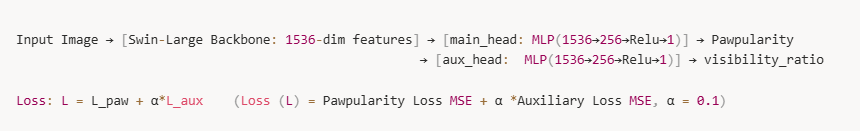


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# 1: imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../.."
img_folder  = os.path.join(main_folder, "data", "train")
out_dir     = os.path.join(main_folder, "outputs", "extra", "exp15_swin_384_strong_MSE_aux_visibility_normalized_MLP_Head")
out_csv     = os.path.join(main_folder, "data", "train_with_visibility.csv")

os.makedirs(out_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#  generate pseudo-labels if not already done, load CSV, set cfg

import sys
sys.path.insert(0, os.path.join(main_folder))
from src.gen_pseudo_labels import generate_pseudo_labels

# --- generate all pseudo-labels (skips if CSV already exists) ---
df_raw = pd.read_csv(os.path.join(main_folder, "data", "train.csv"))

df = generate_pseudo_labels(
    df=df_raw,
    img_folder=img_folder,
    out_csv=out_csv,
    run_brisque=False,
    run_yolo=True,
    force_recompute=False,
)

TARGET = "Pawpularity"
# --- set cfg ---
cfg = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg["img_size"] = 384
cfg["name"]     = "exp15_swin_384_strong_MSE_aux_visibility_normalized_MLP_Head"
cfg["loss"]     = "mse"
cfg["head_type"] = "mlp"

cfg["aux_tasks"] = ["visibility_ratio"]
cfg["aux_loss_weights"] = {"visibility_ratio": 0.1} 

save_config(cfg, out_dir)
set_seed(cfg["seed"])



Pseudo-label CSV already exists, loading: ../../data/train_with_visibility.csv


Pseudo-label statistics:
       visibility_ratio
count          9912.000
mean              0.476
std               0.251
min               0.000
25%               0.288
50%               0.474
75%               0.670
max               0.999

Correlation with Pawpularity:
  visibility_ratio: r = -0.0202


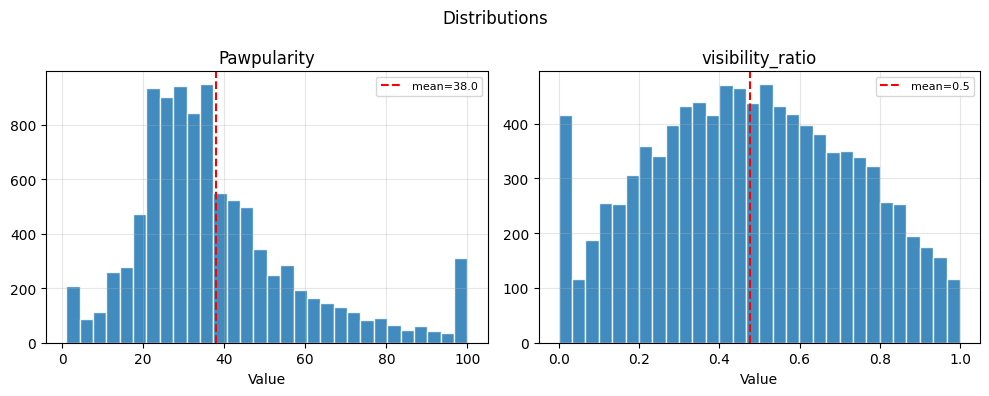

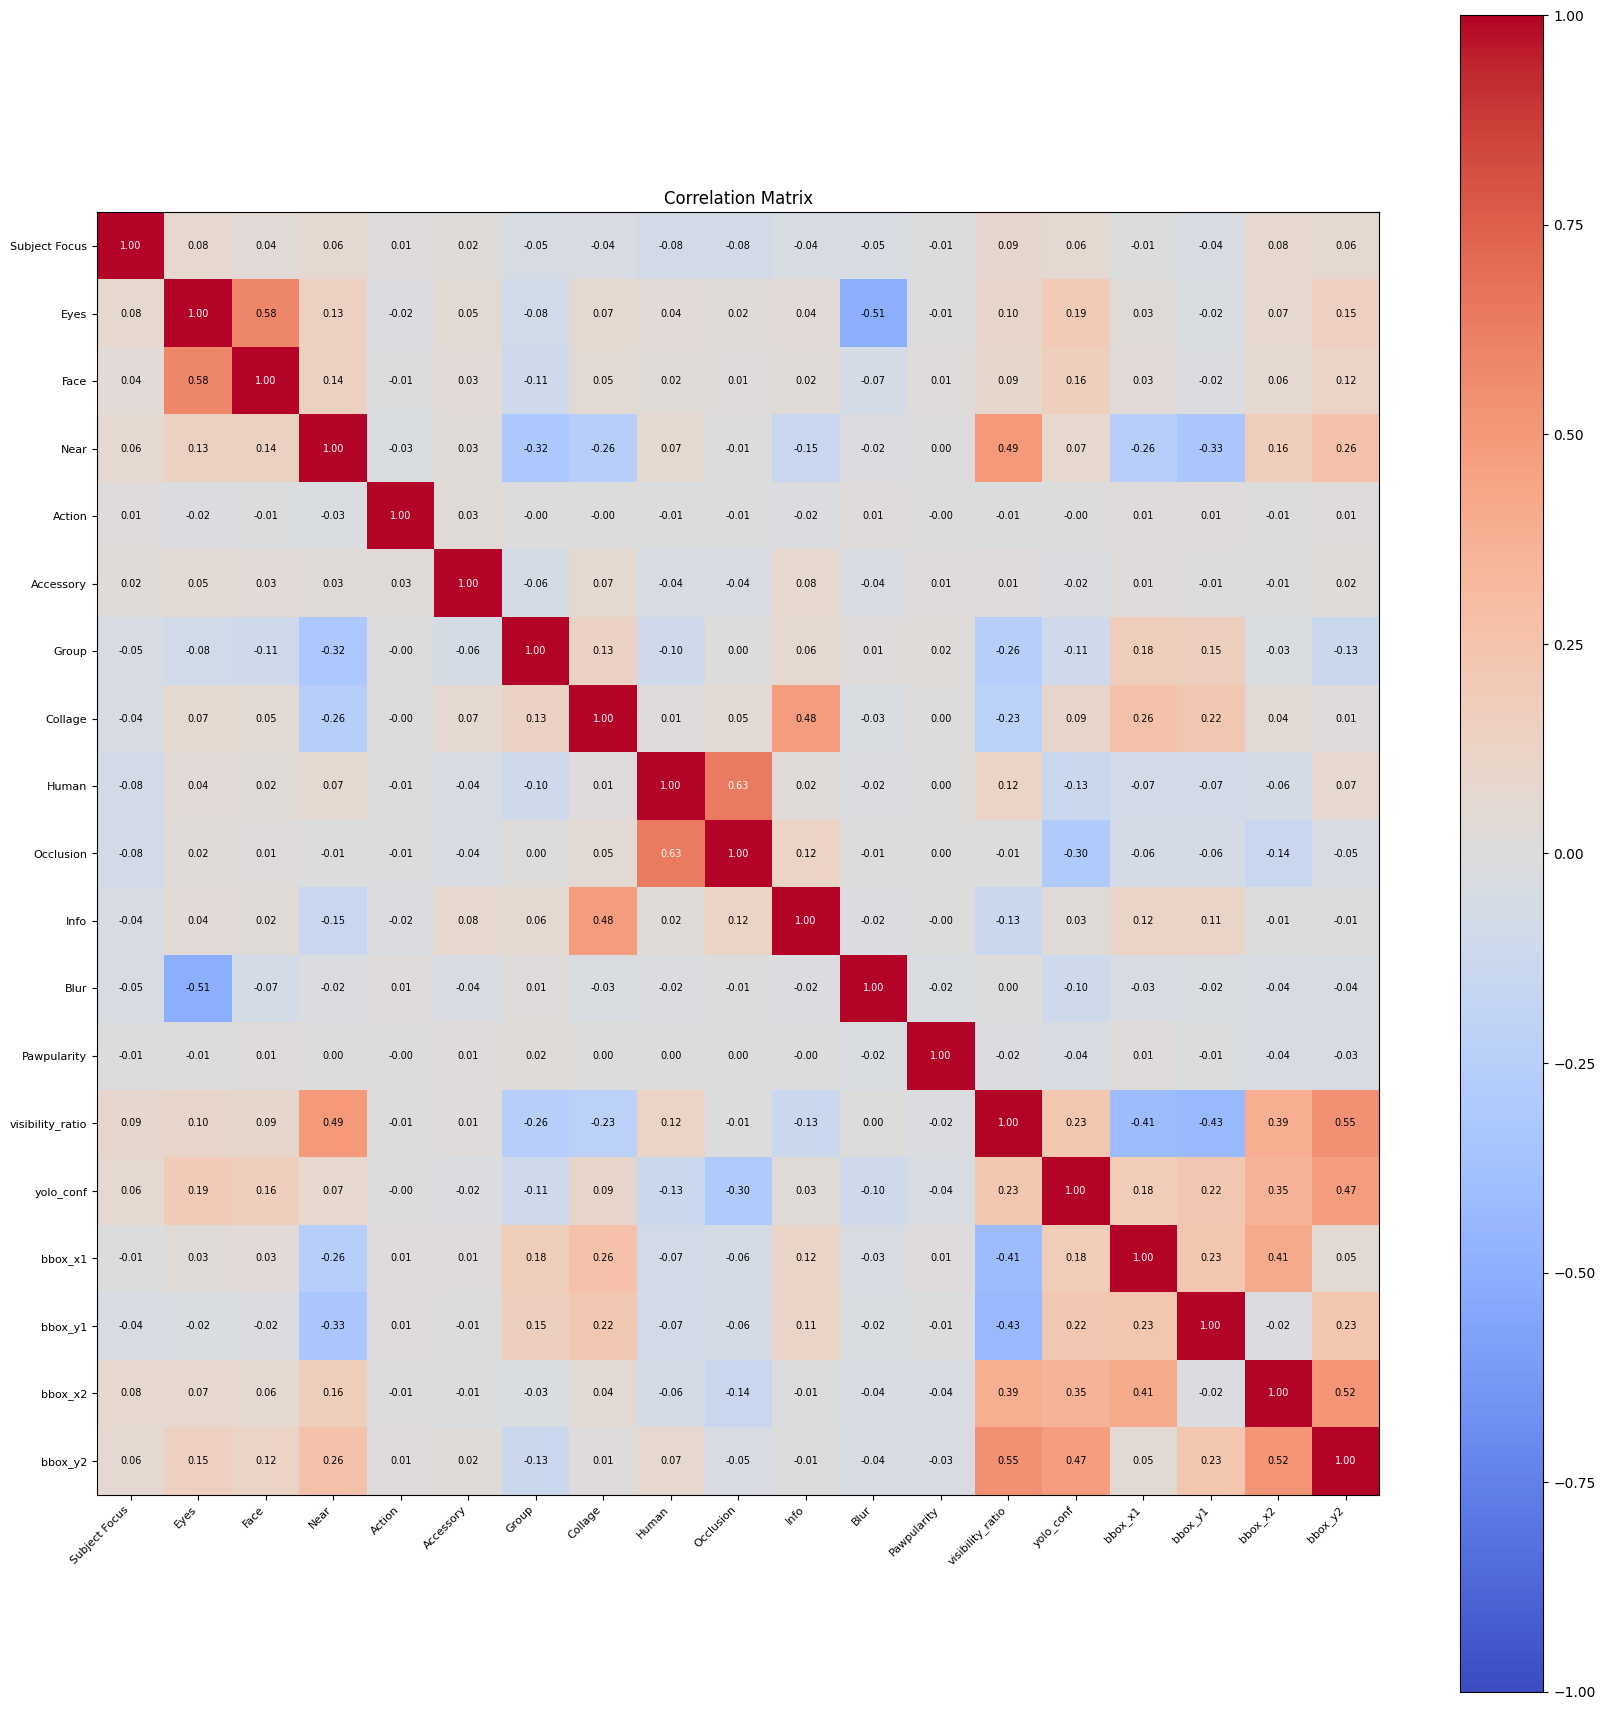

In [5]:


from src.plot import plot_pseudo_label_analysis

pseudo_cols = [c for c in ["BRISQUE", "visibility_ratio"] if c in df.columns]

# simple stats
print("Pseudo-label statistics:")
print(df[pseudo_cols].describe().round(3))

print("\nCorrelation with Pawpularity:")
for col in pseudo_cols:
    r = df[col].corr(df["Pawpularity"])
    print(f"  {col}: r = {r:.4f}")

# plots
plot_pseudo_label_analysis(
    df=df,
    pseudo_cols=pseudo_cols,
    target_col="Pawpularity",
    out_dir=out_dir,
)

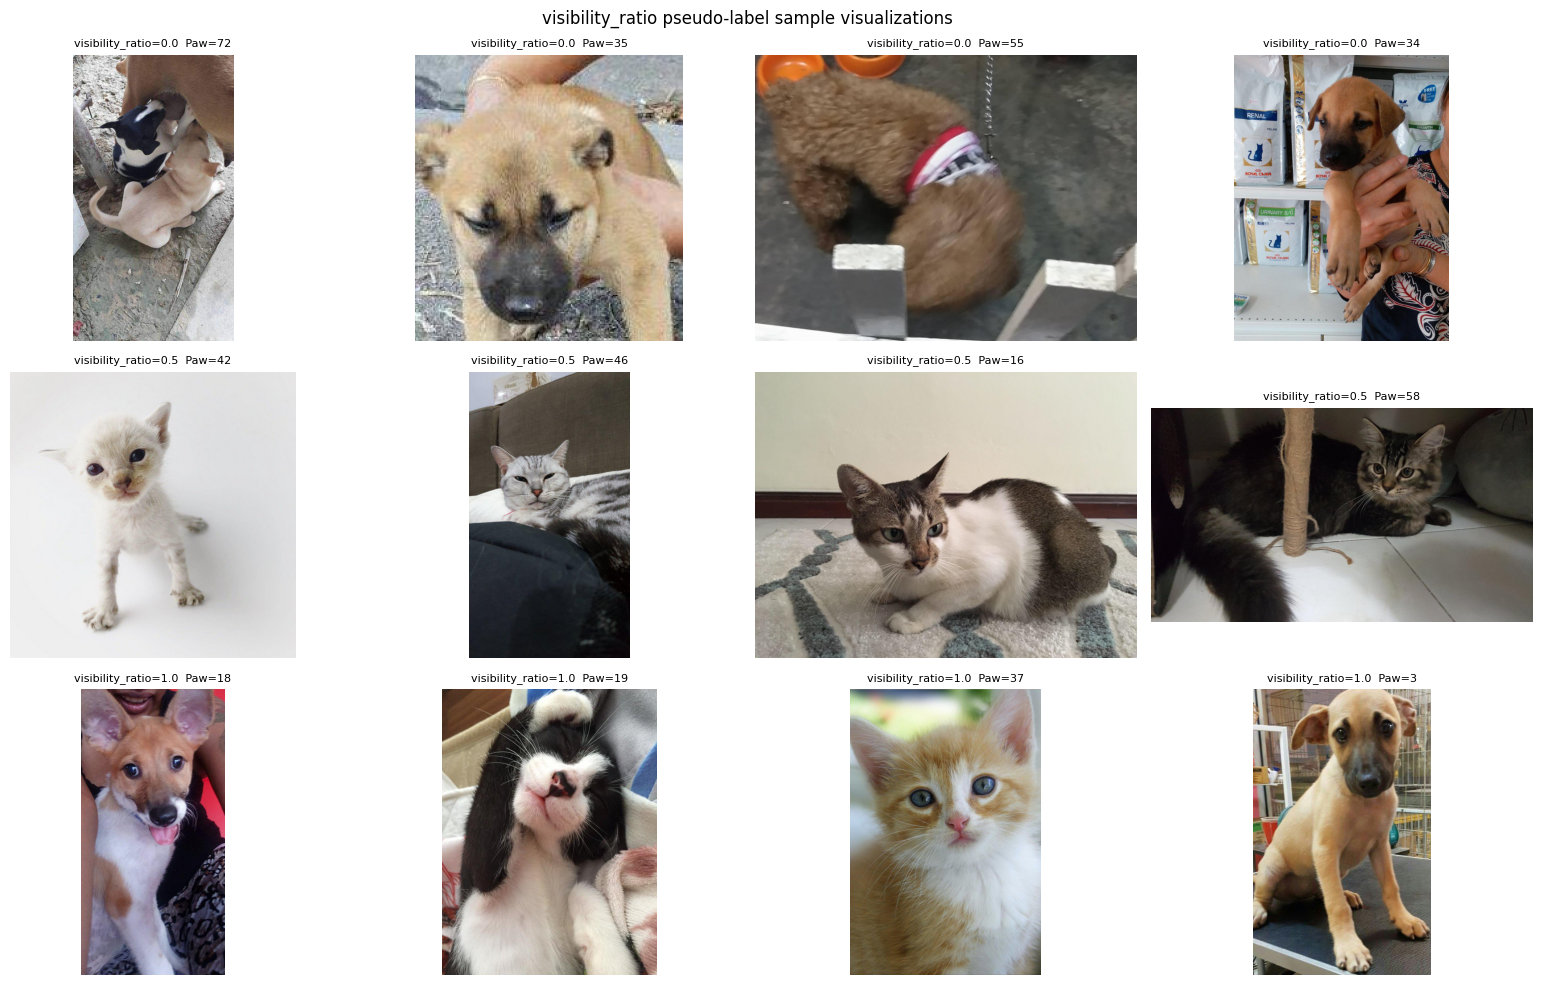

In [6]:
# sample images — low / mid / high visibility_ratio
# shows the pseudo-label

df_vis = df[["Id", "Pawpularity", "visibility_ratio"]].copy()

low  = df_vis.nsmallest(4, "visibility_ratio")
mid  = df_vis.iloc[(df_vis["visibility_ratio"] - df_vis["visibility_ratio"].median()).abs().argsort()[:4]]
high = df_vis.nlargest(4, "visibility_ratio")

groups = [
    ("Low visibility_ratio\n(good quality)",  low),
    ("Mid visibility_ratio",                  mid),
    ("High visibility_ratio\n(poor quality)", high),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for row_idx, (group_label, group_df) in enumerate(groups):
    for col_idx, (_, r) in enumerate(group_df.iterrows()):
        ax = axes[row_idx][col_idx]
        img = Image.open(os.path.join(img_folder, r["Id"] + ".jpg")).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"visibility_ratio={r['visibility_ratio']:.1f}  Paw={r['Pawpularity']}", fontsize=8)
    axes[row_idx][0].set_ylabel(group_label, fontsize=9, rotation=0,
                                labelpad=130, va="center")

plt.suptitle("visibility_ratio pseudo-label sample visualizations", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
#  scale visibility_ratio to [0,100] 
df["visibility_ratio"] = df["visibility_ratio"] * 100
print(f"\nvisibility_ratio scaled to [0,100] in memory")
print(df["visibility_ratio"].describe())


visibility_ratio scaled to [0,100] in memory
count    9912.000000
mean       47.635706
std        25.077246
min         0.000000
25%        28.800346
50%        47.443281
75%        67.000692
max        99.928158
Name: visibility_ratio, dtype: float64


In [8]:

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp15_swin_384_strong_MSE_aux_visibility_normalized_MLP_Head: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: PawRMSE=23.7399 TotalLoss=665.9441 | ValRMSE: 21.0264 | visibility_ratio_val_mse: 635.3215
Epoch 2/10 | Fold 1 | Train[MSE]: PawRMSE=20.5213 TotalLoss=483.5550 | ValRMSE: 21.0136 | visibility_ratio_val_mse: 612.8293
Epoch 3/10 | Fold 1 | Train[MSE]: PawRMSE=19.9229 TotalLoss=441.8522 | ValRMSE: 19.2738 | visibility_ratio_val_mse: 318.5833
Epoch 4/10 | Fold 1 | Train[MSE]: PawRMSE=18.2939 TotalLoss=359.6186 | ValRMSE: 18.4454 | visibility_ratio_val_mse: 251.7218
Epoch 5/10 | Fold 1 | Train[MSE]: PawRMSE=17.1375 TotalLoss=315.2120 | ValRMSE: 18.1302 | visibility_ratio_val_mse: 201.6689
Epoch 6/10 | Fold 1 | Train[MSE]: PawRMSE=16.1715 TotalLoss=281.2749 | ValRMSE: 17.9007 | visibility_ratio_val_mse: 211.6832
Epoch 7/10 | Fold 1 | Train[MSE]: PawRMSE=15.2556 TotalLoss=251.9873 | ValRMSE: 17.9412 | visibility_ratio_val_mse: 229.7702
Epoch 8/10 | Fold 1 | Train[MSE]: PawRMSE=14.43

In [4]:



import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.9007 (n=1983)
Fold 2 OOF RMSE: 18.1496 (n=1983)
Fold 3 OOF RMSE: 17.4411 (n=1982)
Fold 4 OOF RMSE: 17.6298 (n=1982)
Fold 5 OOF RMSE: 18.1148 (n=1982)


In [5]:
# aux-task validation metrics 



baseline_rmse_path = os.path.join(
    "../..", "outputs", "extra", "exp3_swin_384_strong_MSE_MLPHead", "fold_rmse.npy"
)
aux_rmse_path = os.path.join(out_dir, "fold_rmse.npy")

if os.path.exists(baseline_rmse_path) and os.path.exists(aux_rmse_path):
    fold_rmse_base = np.load(baseline_rmse_path)
    fold_rmse_aux  = np.load(aux_rmse_path)

    print(f"\n{'Model':<35} {'Mean':>7} {'Std':>6}  Fold RMSEs")
    print(f"{'Swin image-only (exp3)':<35} "
          f"{fold_rmse_base.mean():>7.4f} {fold_rmse_base.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_base.tolist()]}")
    print(f"{'Swin + visibility_ratio aux (exp15)':<35} "
          f"{fold_rmse_aux.mean():>7.4f} {fold_rmse_aux.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_aux.tolist()]}")




Model                                  Mean    Std  Fold RMSEs
Swin image-only (exp3)              17.7337 0.2876  [17.7702, 18.0767, 17.3341, 17.4841, 18.0031]
Swin + visibility_ratio aux (exp15) 17.8472 0.2750  [17.9007, 18.1496, 17.4411, 17.6298, 18.1148]


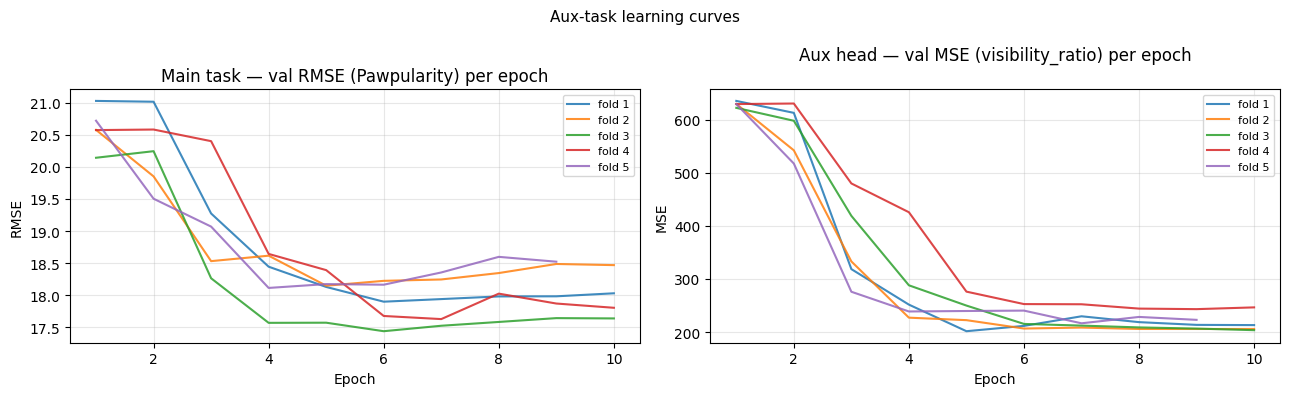

In [6]:
#  per-epoch BRISQUE val MSE curve
# Aux loss

all_logs = []
for fold in range(1, 6):
    lp = os.path.join(out_dir, f"epoch_logs_fold{fold}.csv")
    if os.path.exists(lp):
        all_logs.append(pd.read_csv(lp))

if all_logs:
    logs_df = pd.concat(all_logs).reset_index(drop=True)

    if "visibility_ratio_val_mse" in logs_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        for fold_i in range(1, 6):
            fold_log = logs_df[logs_df["fold"] == fold_i]
            if fold_log.empty:
                continue
            axes[0].plot(fold_log["epoch"], fold_log["val_rmse"],
                         label=f"fold {fold_i}", alpha=0.85)
            axes[1].plot(fold_log["epoch"], fold_log["visibility_ratio_val_mse"],
                         label=f"fold {fold_i}", alpha=0.85)

        axes[0].set_title("Main task — val RMSE (Pawpularity) per epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("RMSE")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        axes[1].set_title("Aux head — val MSE (visibility_ratio) per epoch\n"
                          )
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MSE")
        axes[1].legend(fontsize=8)
        axes[1].grid(alpha=0.3)

        plt.suptitle("Aux-task learning curves", fontsize=11)
        plt.tight_layout()
        
        plt.show()

#     

In [12]:
logs_df.head()

,fold,epoch,train_loss,train_paw_loss,val_rmse,loss_visibility_ratio,visibility_ratio_val_mse
0,1,1,665.944102,563.584701,21.026409,1023.594004,635.321472
1,1,2,483.555020,421.123397,21.013605,624.316218,612.829285
2,1,3,441.852203,396.921120,19.273779,449.310827,318.583344
3,1,4,359.618607,334.668007,18.445438,249.505999,251.721848
4,1,5,315.211998,293.695124,18.130194,215.168738,201.668884


### Training and Validation Loss Curve

In [7]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs","extra", "exp3_swin_384_strong_MSE_MLPHead")


### Side by Side Comparison with Image baseline

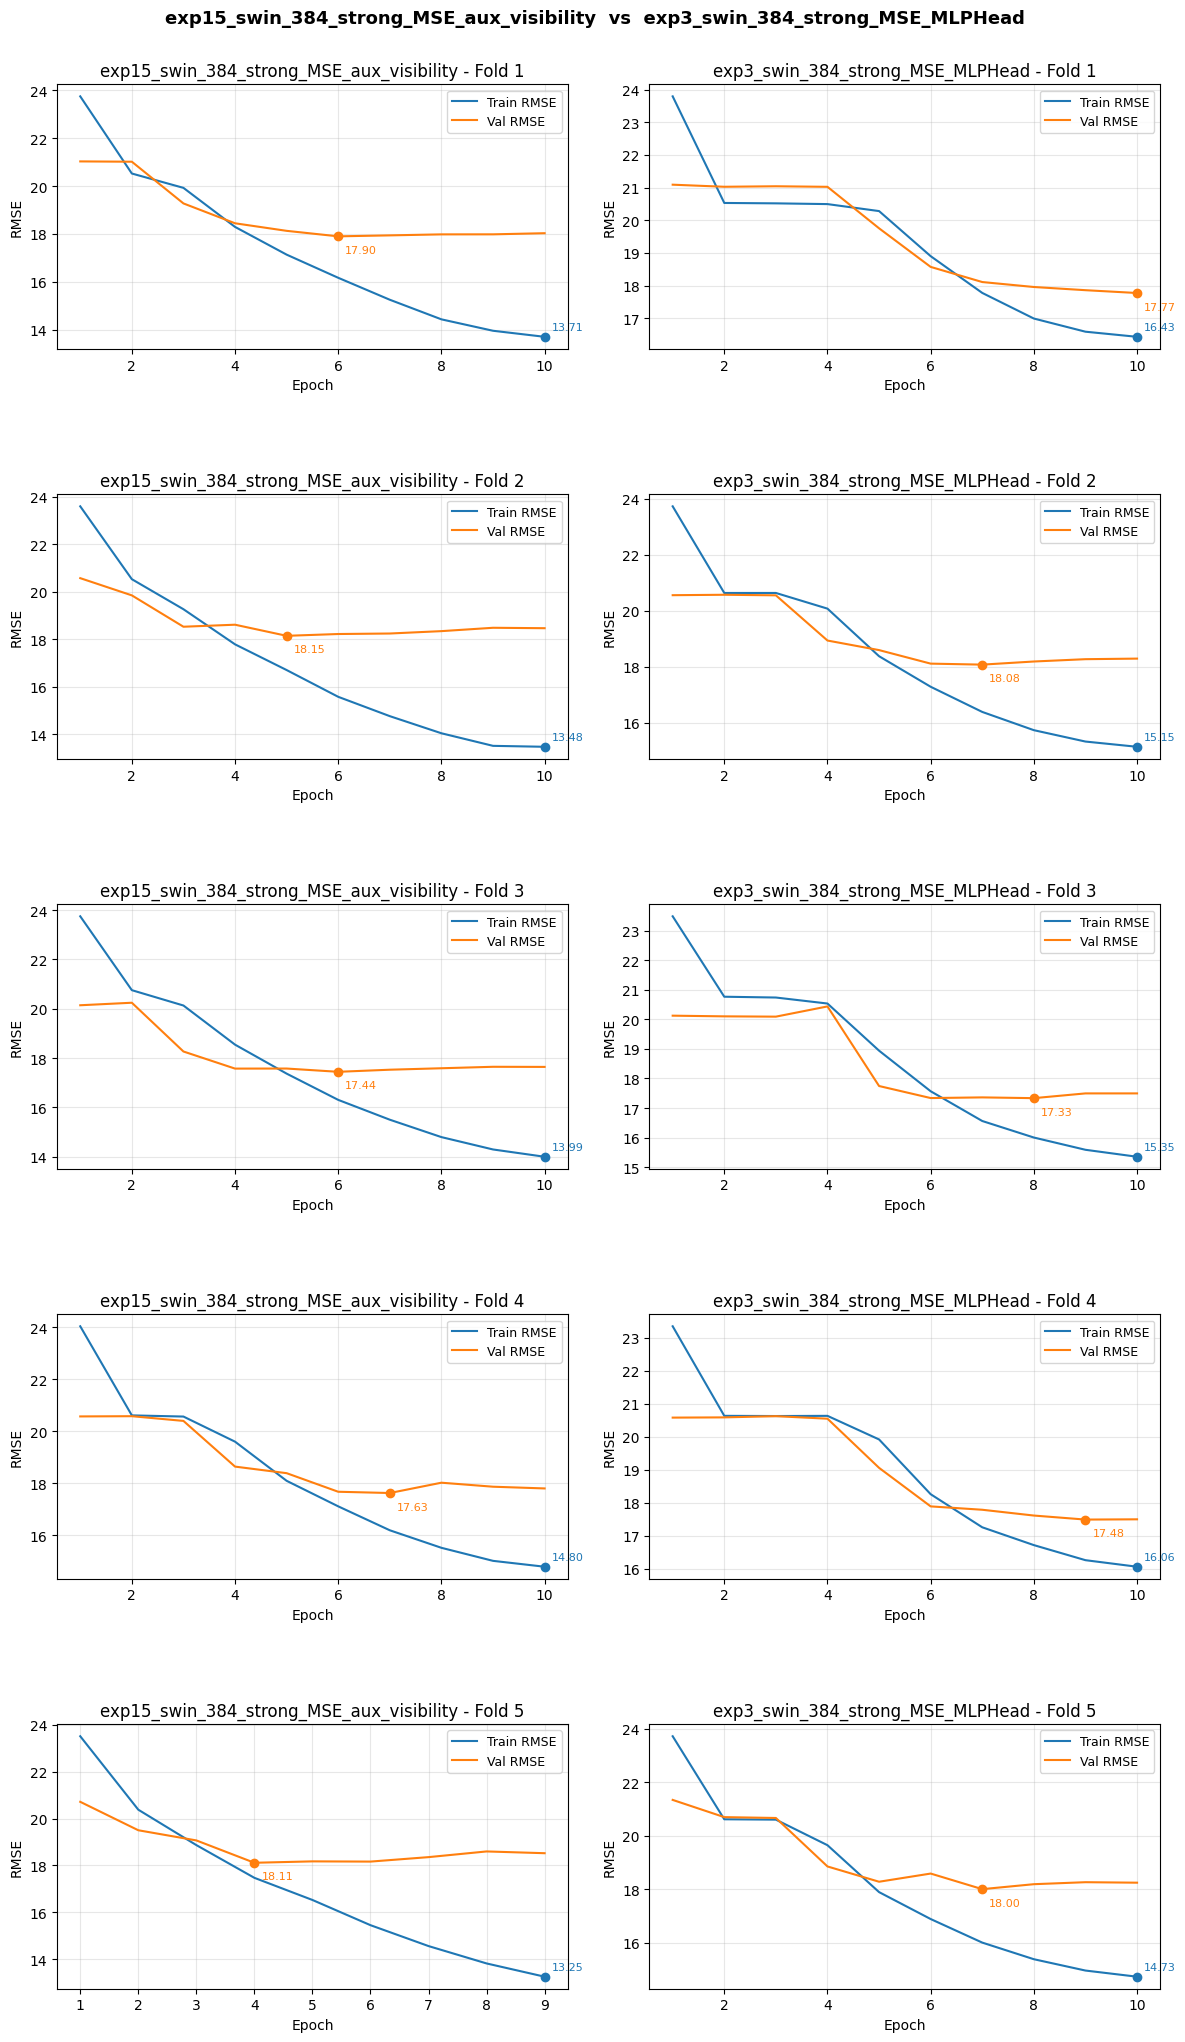

In [8]:
### Side by Side Comparison with Image only
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="exp15_swin_384_strong_MSE_aux_visibility", label_b="exp3_swin_384_strong_MSE_MLPHead")


In [9]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,e638853bdec13e6cc76b69f169b34740,4,96,22.553812,73.446188
1,4435d6f98ad72782ca0cf61f946b016d,5,100,27.648136,72.351864
2,054cef9194f1a4513dc0965893b589bf,3,2,72.932350,70.932350
3,941e532a21f7edb21766e88a15e588cb,4,100,29.429380,70.570620
4,4c1e05895368c997fdd709bbd1ac3dae,2,2,71.942619,69.942619


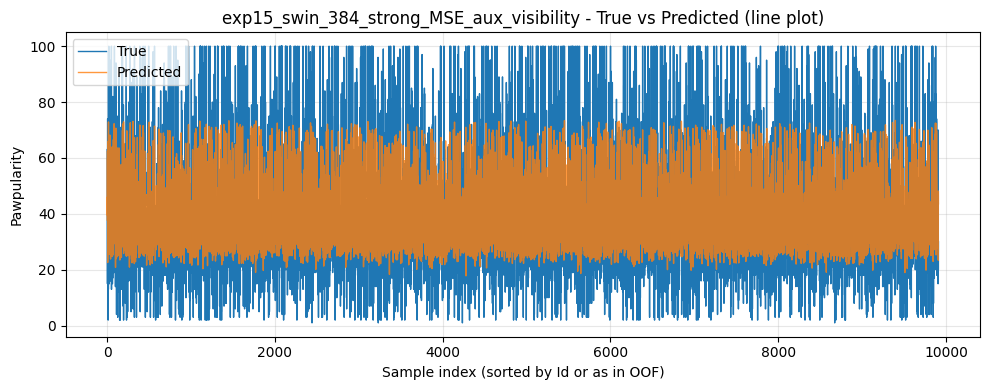

In [10]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="exp15_swin_384_strong_MSE_aux_visibility")





exp15_swin_384_strong_MSE_aux_visibility OOF RMSE: 17.849362597656448
exp3_swin_384_strong_MSE_MLPHead OOF RMSE: 17.73602090865089
ΔRMSE (exp3_swin_384_strong_MSE_MLPHead - exp15_swin_384_strong_MSE_aux_visibility): -0.11334168900555852


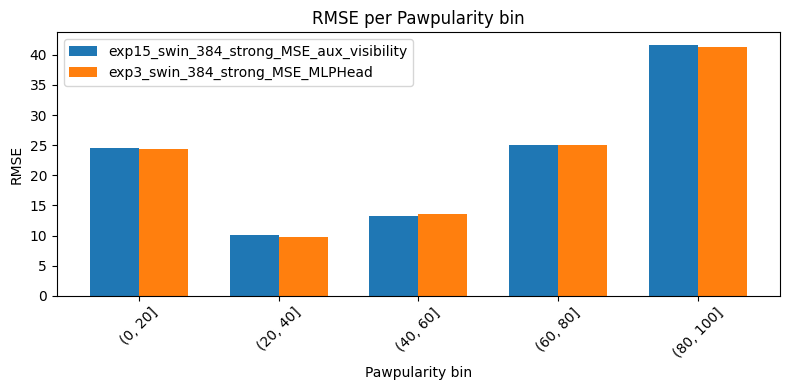

In [11]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="exp15_swin_384_strong_MSE_aux_visibility",
    label_b="exp3_swin_384_strong_MSE_MLPHead",
    title_prefix="",
)

In [12]:
df_bins.head()

,bin,count,exp15_swin_384_strong_MSE_aux_visibility_rmse,exp3_swin_384_strong_MSE_MLPHead_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.505396,24.383091,-0.122305,exp3_swin_384_strong_MSE_MLPHead_better
1,"(20, 40]",5119,10.055836,9.719382,-0.336454,exp3_swin_384_strong_MSE_MLPHead_better
2,"(40, 60]",2088,13.187647,13.504186,0.316539,exp15_swin_384_strong_MSE_aux_visibility_better
3,"(60, 80]",727,24.967614,25.028708,0.061094,exp15_swin_384_strong_MSE_aux_visibility_better
4,"(80, 100]",561,41.647624,41.275555,-0.372068,exp3_swin_384_strong_MSE_MLPHead_better


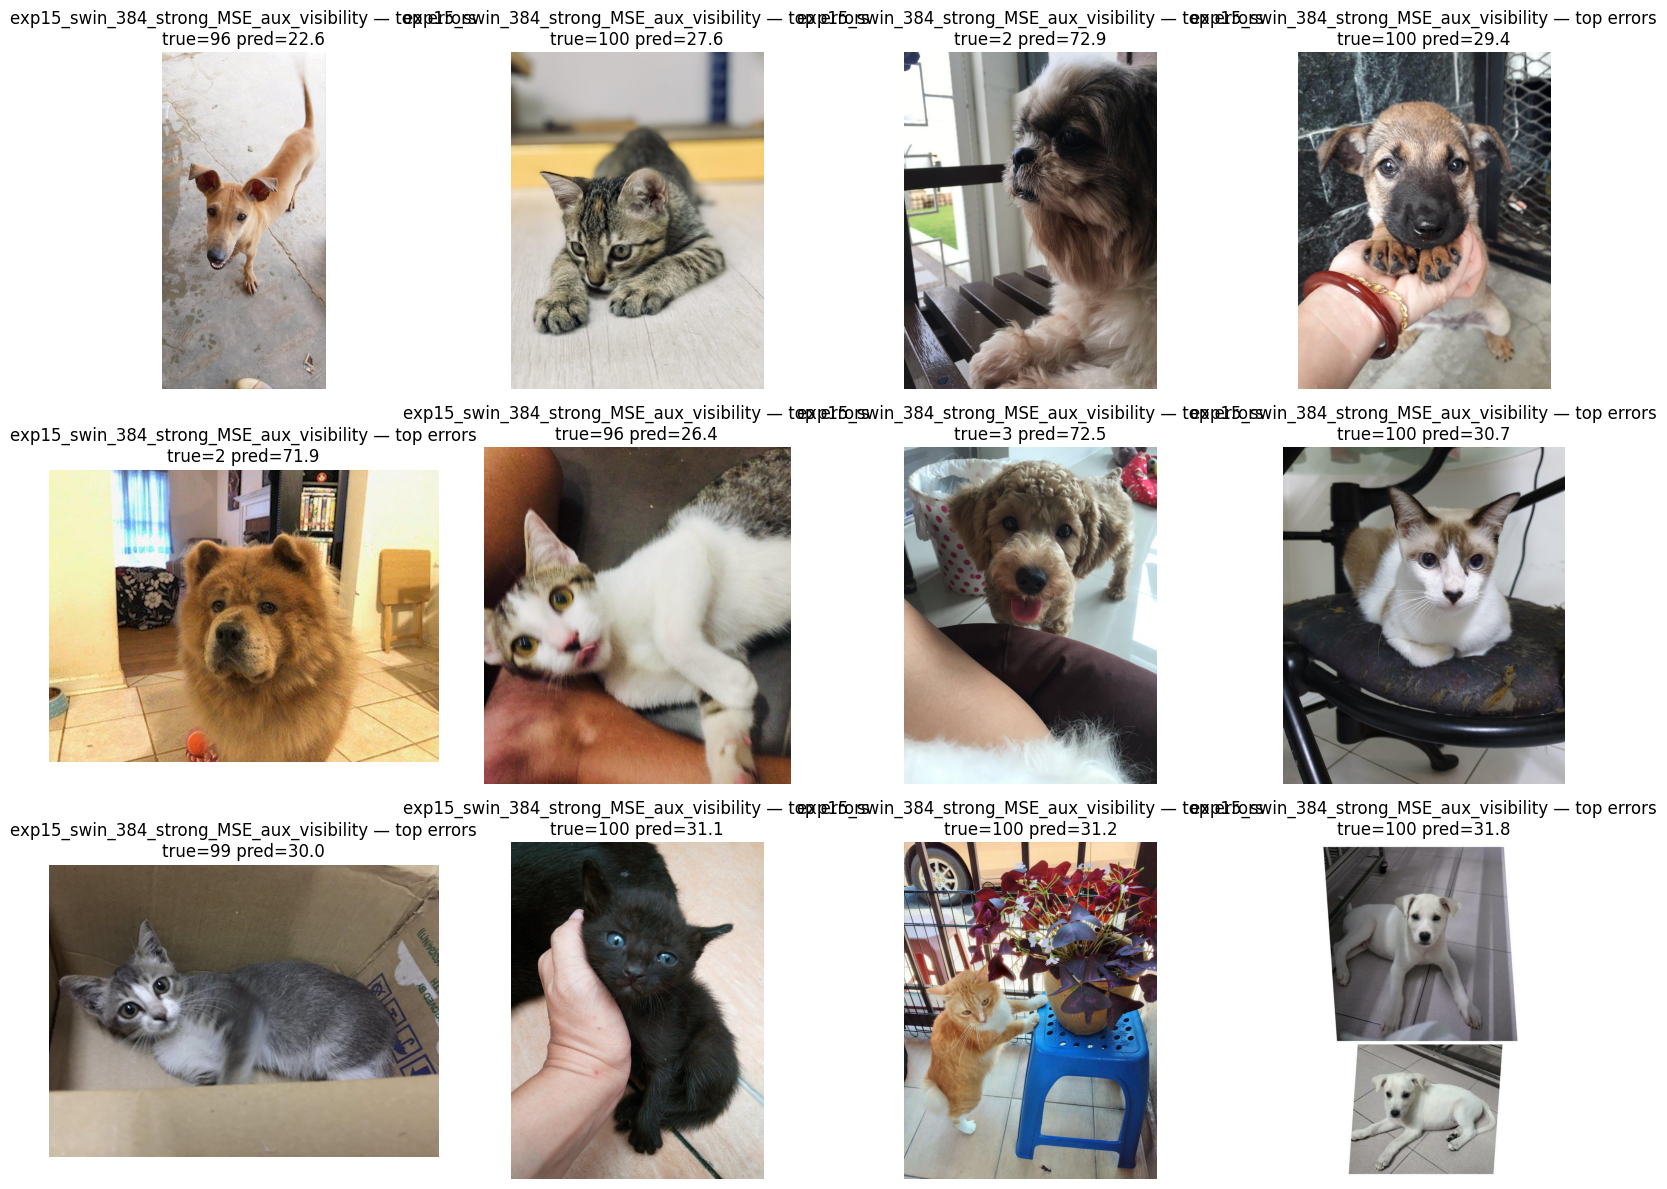

In [13]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp15_swin_384_strong_MSE_aux_visibility — top errors")

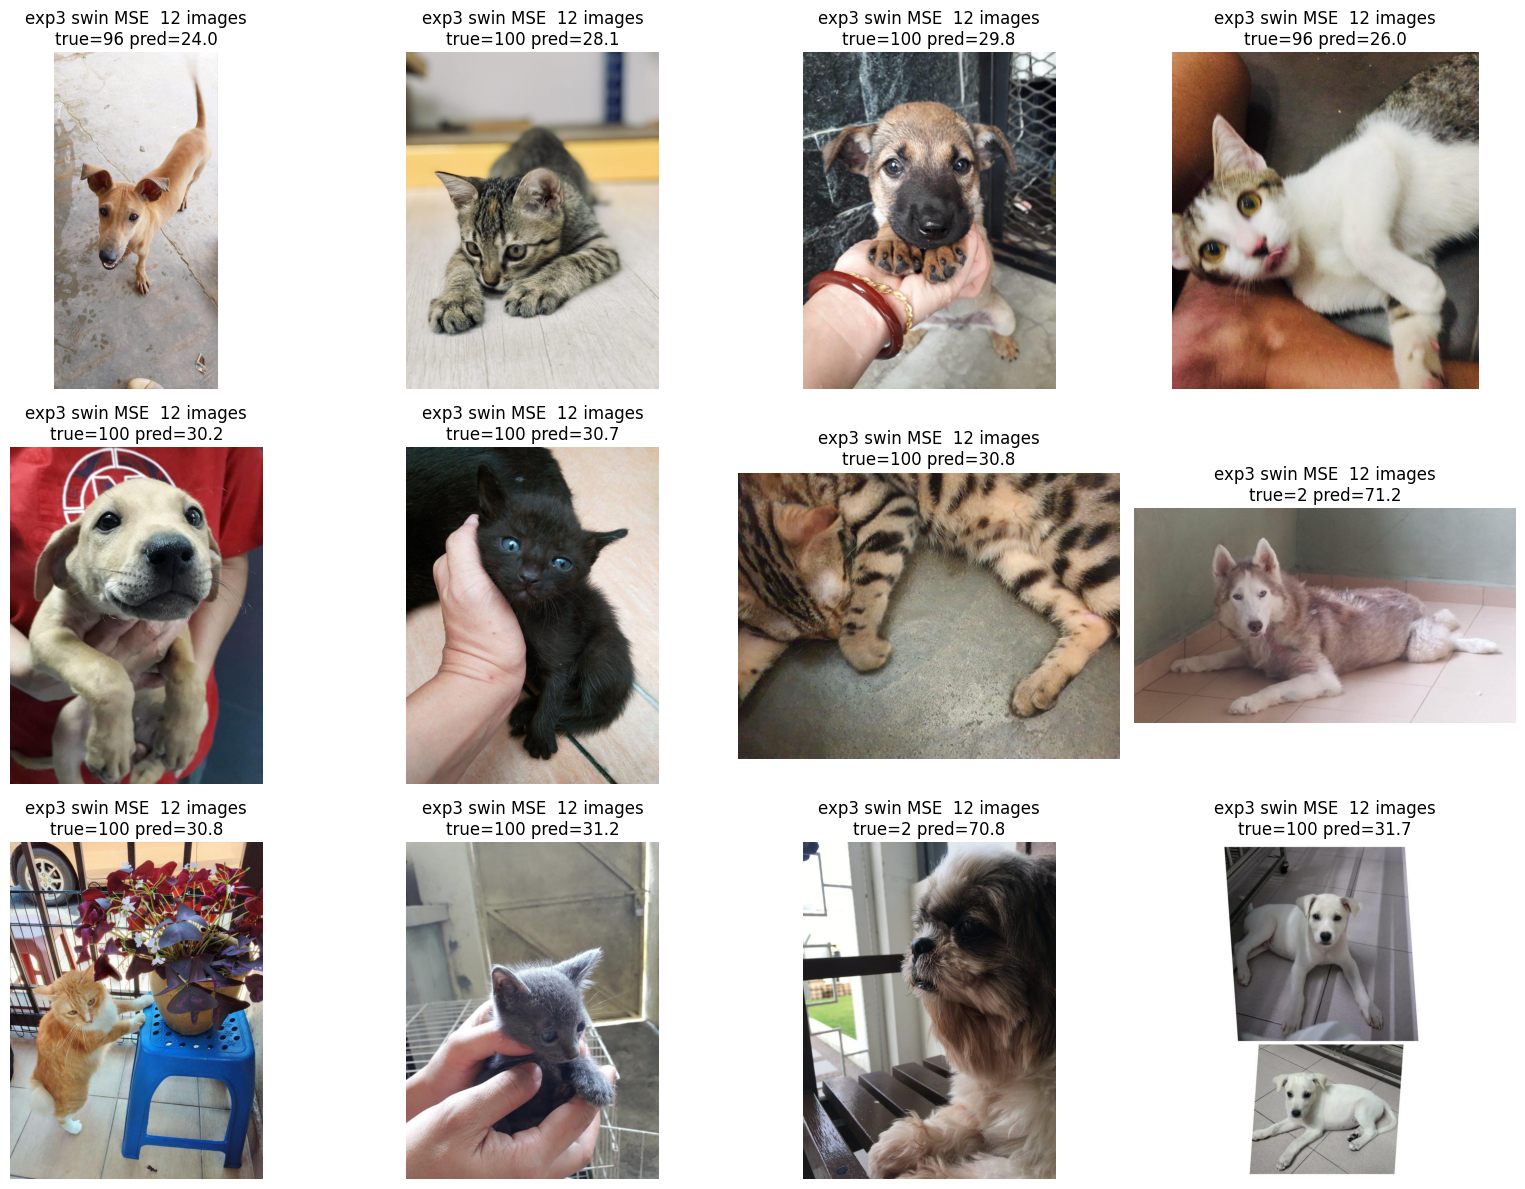

In [14]:
# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp3 swin MSE  12 images")